<a href="https://colab.research.google.com/github/elianramon/Challenge_3_TelecomX_2_CD_ONE/blob/main/TeleconX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SOBRE

## **Telecom $X$ - Análise de Evasão de Clientes**
_______

Você foi contratado como assistente de análise de dados na Telecom X e fará parte do projeto "Churn de Clientes". A empresa enfrenta um alto índice de cancelamentos e precisa entender os fatores que levam à perda de clientes.

Seu desafio será coletar, tratar e analisar os dados, utilizando Python e suas principais bibliotecas para extrair insights valiosos. A partir da sua análise, os demais colegas da  equipe de Data Science poderá avançar para modelos preditivos e desenvolver estratégias para reduzir a evasão.

## Imports

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import requests

## Extração de Dados

In [75]:
# Dados estão no formato JSON

tele_x = pd.read_json("https://raw.githubusercontent.com/alura-cursos/challenge2-data-science/refs/heads/main/TelecomX_Data.json")

tele_x.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


### Conversão para df

In [76]:
response = requests.get("https://raw.githubusercontent.com/alura-cursos/challenge2-data-science/refs/heads/main/TelecomX_Data.json")
data = response.json()

df = pd.json_normalize(data)             # "Achata" o JSON para que cada chave vire uma coluna individual

df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


### Tirando a palavra "costumer"

In [77]:
# Lista de prefixos que você deseja remover
prefixos = ['customer.', 'phone.', 'internet.', 'account.', 'Charges.']

# O regex r'|'.join(prefixos) cria o padrão: 'customer\.|phone\.|internet\.|account\.'
# O '\' escapa o ponto para garantir que o pandas entenda como um ponto literal
df.columns = df.columns.str.replace(r'|'.join(prefixos), '', regex=True)

df.head()

,D,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


### Verificações de Problemas

In [78]:
def caracteristicas (dataset):
    print(f'Tamanho: {dataset.shape}\n')
    print(f'Colunas: {dataset.columns}\n')
    print(f'Informações: {dataset.info()}\n')
    print(f'Descrição: {dataset.describe()}\n')
    print(f'Valores nulos: {dataset.isnull().sum()}')

In [79]:
caracteristicas(df)

Tamanho: (7267, 21)

Colunas: Index(['D', 'Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'Monthly', 'Total'],
      dtype='object')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   D                 7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-nu

### Valores Únicos

Como a avaliação anterior não encontrou erros, vamos abordar uma verificação de valores únicos.

In [80]:
# Retorna apenas o número total de valores diferentes
df.nunique()

,0
D,7267
Churn,3
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,73
PhoneService,2
MultipleLines,3
InternetService,3


In [81]:
df["Churn"].unique()

array(['No', 'Yes', ''], dtype=object)

In [82]:
df["Churn"].isnull().sum()

np.int64(0)

### Valor Nulo?

# ***Valor vazio é diferente de valor nulo!***

In [83]:
# Substitui as strings vazias por NaN em todo o DataFrame
df.replace('', np.nan, inplace=True)

# Agora, tente rodar o comando novamente:
print(df.isnull().sum())

D                     0
Churn               224
gender                0
SeniorCitizen         0
Partner               0
Dependents            0
tenure                0
PhoneService          0
MultipleLines         0
InternetService       0
OnlineSecurity        0
OnlineBackup          0
DeviceProtection      0
TechSupport           0
StreamingTV           0
StreamingMovies       0
Contract              0
PaperlessBilling      0
PaymentMethod         0
Monthly               0
Total                 0
dtype: int64


Encontramos! Vamos tratar!

In [84]:
# Remove apenas as linhas onde a coluna Churn está vazia

df = df.dropna(subset=['Churn'])

In [85]:
df["Churn"].unique()

array(['No', 'Yes'], dtype=object)

In [86]:
df

,D,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


As linhas foram removidas com sucesso.

Por fim, fazer um mapeamento na variável $SeniorCitizen$ para padronizar em $No$ e $Yes$

## Remoção de Colunas


In [87]:
df = df.drop(columns=['D'])


## Transformando para 0 e 1

_______

# 0 indica não

# 1 indica sim

In [107]:
# Identifica colunas que contêm 'yes' ou 'no' e aplica a mudança

df['gender'] = df['gender'].replace({'Female': 1, 'Male': 0})
df['Contract'] = df['Contract'].replace({'One year':0, 'Month-to-month':1, 'Two year':2})
df['InternetService'] = df['InternetService'].replace({'DSL':1, 'Fiber optic':2, 'No internet service':3})
df['MultipleLines'] = df['MultipleLines'].replace({'No phone service':2})
df['PaymentMethod'] = df['PaymentMethod'].replace({'Mailed check':0, 'Electronic check':1, 'Credit card (automatic)':2,
       'Bank transfer (automatic)':3})

for col in df.columns:
    if df[col].dtype == 'object':
        if 'Yes' in df[col].values or 'No' in df[col].values:
            df[col] = df[col].replace({'Yes': 1, 'No': 0})

df.describe

<bound method NDFrame.describe of       Churn  gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0         0       1              0        1           1       9             1   
1         0       0              0        0           0       9             1   
2         1       0              0        0           0       4             1   
3         1       0              1        1           0      13             1   
4         1       1              1        1           0       3             1   
...     ...     ...            ...      ...         ...     ...           ...   
7262      0       1              0        0           0      13             1   
7263      1       0              0        1           0      22             1   
7264      0       0              0        0           0       2             1   
7265      0       0              0        1           1      67             1   
7266      0       0              0        1           1      63             0   

      MultipleLines  InternetService OnlineSecurity OnlineBackup  \
0                 0                1              0            1   
1                 1                1              0            0   
2                 0                2              0            0   
3                 0                2              0            1   
4                 0                2              0            0   
...             ...              ...            ...          ...   
7262              0                1              1            0   
7263              1                2              0            0   
7264              0                1              0            1   
7265              0                1              1            0   
7266              2                1              1            1   

     DeviceProtection TechSupport StreamingTV StreamingMovies  Contract  \
0                   0           1           1               0         0   
1                   0           0           0               1         1   
2                   1           0           0               0         1   
3                   1           0           1               1         1   
4                   0           1           1               0         1   
...               ...         ...         ...             ...       ...   
7262                0           1           0               0         0   
7263                0           0           0               1         1   
7264                0           0           0               0         1   
7265                1           1           0               1         2   
7266                1           0           1               1         2   

      PaperlessBilling  PaymentMethod  Monthly    Total  
0                    1              0    65.60    593.3  
1                    0              0    59.90    542.4  
2                    1              1    73.90   280.85  
3                    1              1    98.00  1237.85  
4                    1              0    83.90    267.4  
...                ...            ...      ...      ...  
7262                 0              0    55.15    742.9  
7263                 1              1    85.10   1873.7  
7264                 1              0    50.30    92.75  
7265                 0              0    67.85  4627.65  
7266                 0              1    59.00   3707.6  

[7043 rows x 20 columns]>

In [105]:
df['interleave'].unique()

KeyError: 'interleave'

Contagem de Clientes:
Churn
0    5174
1    1869
Name: count, dtype: int64

Proporção das Classes (%):
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


<Axes: xlabel='Churn'>

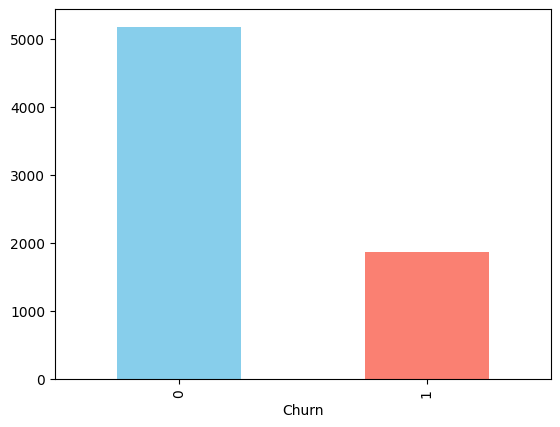

In [90]:
import pandas as pd

# 1. Contagem absoluta de cada classe
contagem = df['Churn'].value_counts()

# 2. Cálculo da proporção percentual
proporcao = df['Churn'].value_counts(normalize=True) * 100

# Exibindo os resultados
print("Contagem de Clientes:")
print(contagem)
print("\nProporção das Classes (%):")
print(proporcao)

# 3. Visualização rápida (opcional mas recomendada)
df['Churn'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])

In [104]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calcular a matriz de correlação (apenas para colunas numéricas)
corr_matrix = df.corr()

# 2. Configurar o tamanho da figura
plt.figure(figsize=(12, 8))

# 3. Criar o Heatmap
# annot=True exibe os valores numéricos dentro dos quadrados
# cmap='coolwarm' usa azul para correlação negativa e vermelho para positiva
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)

plt.title('Matriz de Correlação das Variáveis')
plt.show()

# 4. Dica: Isolar a correlação apenas com a variável alvo (ex: 'Churn')
# Isso ajuda a focar no que realmente importa para o modelo
print("\nCorrelação direta com a Evasão (Churn):")
print(corr_matrix['Churn'].sort_values(ascending=False))


ValueError: could not convert string to float: 'No internet service'